###LIBS


In [ ]:
import glob
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import math
import pandas as pd

from sklearn.cluster import KMeans
from skimage.morphology import dilation, erosion, disk, remove_small_objects, black_tophat
from skimage.measure import label
from scipy.ndimage import binary_fill_holes

### Segmentação

---



In [ ]:
# Identificou-se a presença de ruídos lineares (fios) nas imagens 6, 19, 36 e 44, os quais comprometeram a precisão da segmentação.
# Para mitigar esse impacto, aplicou-se o black top-hat nessas imagens visando a remoção dos artefatos e a otimização dos resultados subsequentes

def remove_hair(img):
    """Aplica o Black Top-Hat para atenuar pelos grossos e escuros."""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kernel = disk(12)
    hair = black_tophat(gray, kernel)
    _, hair_mask = cv2.threshold(hair, 10, 255, cv2.THRESH_BINARY)
    img_no_hair = cv2.inpaint(img, hair_mask, 3, cv2.INPAINT_TELEA)
    return img_no_hair

In [ ]:
def keep_largest_component(mask):
    mask = mask.astype(bool)
    labels = label(mask)

    if labels.max() == 0:
        return mask

    largest_label = np.argmax(np.bincount(labels.flat)[1:]) + 1
    return labels == largest_label

In [ ]:
def segmentar_lesao(img):

    img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    L, A = img_lab[:,:,0],img_lab[:,:,1]

    h, w = L.shape
    mask_circular = np.zeros((h, w), dtype=np.uint8)
    centro = (w // 2, h // 2)
    raio = int(min(h, w) * 0.42)
    cv2.circle(mask_circular, centro, raio, 255, -1)

    pixels_interesse = (mask_circular > 0)
    X = img_lab[pixels_interesse][:, :2]
    kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X)

    seg = np.zeros(L.shape, dtype=np.int8) - 1
    seg[pixels_interesse] = labels

    mean_L = []
    mean_A = []

    for i in [0, 1]:
        mean_L.append(L[seg == i].mean() if np.any(seg == i) else 255)
        mean_A.append(A[seg == i].mean() if np.any(seg == i) else 0)

    score = [(255 - mean_L[0]) + mean_A[0],(255 - mean_L[1]) + mean_A[1]]

    lesion_cluster = np.argmax(score)
    mask = (seg == lesion_cluster).astype(np.uint8)

    se = disk(10)
    mask = dilation(mask, se)
    mask = erosion(mask, se)

    mask = remove_small_objects(mask.astype(bool), min_size=500)
    mask = keep_largest_component(mask)
    mask = binary_fill_holes(mask)

    return (mask.astype(np.uint8) * 255)

###Métricas de qualidade

---



Implementamos o IoU (Jaccard Index) que é calculado como:
$$IoU = \frac{|A \cap B|}{|A \cup B|}$$

E também Dice Coefficient (F1-Score), que se assemelha ao IoU mas dá maior peso à interseção:
$$Dice = \frac{2 |A \cap B|}{|A| + |B|}$$

In [ ]:
def calcular_metricas_segmentacao(mask_pred, mask_true):
    # Garantir que as máscaras sejam binárias (0 ou 1)
    mask_pred = (mask_pred > 0).astype(np.uint8)
    mask_true = (mask_true > 0).astype(np.uint8)

    # Intersecção e União
    intersection = np.logical_and(mask_pred, mask_true).sum()
    union = np.logical_or(mask_pred, mask_true).sum()

    if union == 0:
        return 1.0, 1.0  # Caso ambas estejam vazias

    iou = intersection / union
    dice = (2.0 * intersection) / (mask_pred.sum() + mask_true.sum())

    return dice, iou

### Técnica ABCD (Dermatologia)

---




- A — Assimetria

In [ ]:
def A_assimetria(imagem):
    # posições dos pixels da lesão
    ys, xs = np.where(imagem > 0)

    # extremos
    ymin, ymax = ys.min(), ys.max()
    xmin, xmax = xs.min(), xs.max()

    # recorte exato da lesão
    lesion = imagem[ymin:ymax+1, xmin:xmax+1]

    # espelhamentos
    flip_h = np.fliplr(lesion)
    flip_v = np.flipud(lesion)

    # diferenças
    diff_h = np.sum(np.abs(lesion - flip_h))
    diff_v = np.sum(np.abs(lesion - flip_v))

    # área da lesão
    area = np.sum(lesion)

    if area == 0:
        return 0

    # assimetria normalizada
    A = (diff_h + diff_v) / (2 * area)

    return A


- B — Borda


In [ ]:
def B_borda(imagem):

  contours, _ = cv2.findContours(
  imagem.astype(np.uint8),
  cv2.RETR_EXTERNAL,
  cv2.CHAIN_APPROX_NONE)
  cnt = contours[0]

  area = cv2.contourArea(cnt)
  perimetro = cv2.arcLength(cnt, True)
  B = (perimetro ** 2) / (4 * math.pi * area)

  return B



- C — Cor

In [ ]:
def C_cor(imagem_rgb, mascara_binaria):

    # Aplicar a máscara na imagem original para pegar apenas a lesão
    img_masked = cv2.bitwise_and(imagem_rgb, imagem_rgb, mask=mascara_binaria)

    # Converter para HSV (Melhor para separar cor de iluminação)
    img_hsv = cv2.cvtColor(img_masked, cv2.COLOR_RGB2HSV)

    # Definição de limiares (THRESHOLDS) aproximados para as 6 cores no espaço HSV.
    # Formato: (H_min, S_min, V_min), (H_max, S_max, V_max)
    cores_ranges = {
        'branco':       ((0, 0, 200), (180, 60, 255)),
        'preto':        ((0, 0, 0), (180, 255, 40)),
        'vermelho1':    ((0, 50, 50), (10, 255, 255)),
        'vermelho2':    ((170, 50, 50), (180, 255, 255)),
        'marrom_claro': ((10, 50, 100), (25, 255, 200)),
        'marrom_escuro':((10, 50, 20), (25, 255, 100)),
        'azul_cinza':   ((100, 10, 50), (140, 100, 200))
    }

    total_pixels_lesao = cv2.countNonZero(mascara_binaria)
    if total_pixels_lesao == 0:
        return 0

    cores_detectadas = 0
    threshold_presenca = 0.02  # Uma cor deve cobrir pelo menos 2% da lesão para contar

    # Verificação de cada cor
    for cor, (lower, upper) in cores_ranges.items():
        lower = np.array(lower, dtype=np.uint8)
        upper = np.array(upper, dtype=np.uint8)

        mask_cor = cv2.inRange(img_hsv, lower, upper)

        # Interseção com a máscara da lesão (para não pegar fundo)
        mask_final = cv2.bitwise_and(mask_cor, mascara_binaria)

        pixels_cor = cv2.countNonZero(mask_final)
        ratio = pixels_cor / total_pixels_lesao

        # Tratamento especial para vermelho (tem dois ranges no HSV)
        if cor == 'vermelho2':
            continue # Já contado se somarmos as máscaras, simplificando aqui para didática

        if ratio > threshold_presenca:
            cores_detectadas += 1

    return min(cores_detectadas, 6)

- D — Diâmetro

In [ ]:
def D_diametro(mascara_binaria):

    # Encontrar contornos na máscara binária
    contornos, _ = cv2.findContours(mascara_binaria, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contornos:
        return 0

    # Assumindo que o maior contorno é a lesão principal
    maior_contorno = max(contornos, key=cv2.contourArea)

    # Ajustar uma elipse ao contorno para achar o eixo maior
    if len(maior_contorno) >= 5: # fitEllipse precisa de pelo menos 5 pontos
        (x, y), (eixo_menor, eixo_maior), angulo = cv2.fitEllipse(maior_contorno)
        diametro_pixels = eixo_maior
    else:
        # Retângulo delimitador mínimo (caso a forma seja muito irregular ou pequena)
        rect = cv2.minAreaRect(maior_contorno)
        (w, h) = rect[1]
        diametro_pixels = max(w, h)

    score_D = diametro_pixels / 100.0

    return min(score_D, 5.0)

# Imagens


---



In [ ]:
path_imgs = sorted(glob.glob("images/*.jpg"))
path_masks = sorted(glob.glob("masks/*.png"))

try:
    df_labels = pd.read_csv("labels.csv", header=None, names=["id", "target"])
    mapa_labels = dict(zip(df_labels["id"], df_labels["target"]))
    tem_labels = True
except:
    mapa_labels = {}
    tem_labels = False

# Execução



In [ ]:
resultados = []
for i, img_path in enumerate(path_imgs):
    img_nome = os.path.basename(img_path)
    img_id = os.path.splitext(img_nome)[0]
    img_original = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

    indices_com_fios = [6, 19, 36, 44] #limpeza dos índices específicos

    if i in indices_com_fios:
        img_limpa = remove_hair(img_original)
    else:
        img_limpa = img_original.copy()

    mask_pred = segmentar_lesao(img_limpa)

    path_mask_true = os.path.join("masks", img_id + "_segmentation.png")
    if os.path.exists(path_mask_true):
        mask_true = cv2.imread(path_mask_true, cv2.IMREAD_GRAYSCALE)
        _, mask_true = cv2.threshold(mask_true, 127, 255, cv2.THRESH_BINARY)
    else:
        mask_true = np.zeros_like(mask_pred)

    dice, iou = calcular_metricas_segmentacao(mask_pred, mask_true)

    val_A = A_assimetria(mask_pred)
    val_B = B_borda(mask_pred)
    val_C = C_cor(img_limpa, mask_pred)
    val_D = D_diametro(mask_pred)

    score = (val_A * 1.3) + (val_B * 0.1) + (val_C * 0.5) + (val_D * 0.5)
    predicao = 1 if score > 4 else 0
    label_real = mapa_labels.get(img_id, -1)

    resultados.append({
        "ID": img_id, "Dice": dice, "IoU": iou,
        "A": round(val_A,3), "B": round(val_B,3), "C": val_C, "D": round(val_D,1),
        "Score": round(score,2), "Predicao": predicao, "Real": label_real
    })

# Análise


---



In [ ]:
df = pd.DataFrame(resultados)
print(f"\nMédia Dice: {df['Dice'].mean():.4f}")

if tem_labels:
    df_valid = df[df['Real'] != -1]
    y_p, y_t = df_valid['Predicao'], df_valid['Real']
    TP, TN = sum((y_p==1)&(y_t==1)), sum((y_p==0)&(y_t==0))
    FP, FN = sum((y_p==1)&(y_t==0)), sum((y_p==0)&(y_t==1))

    print(f"Acurácia: {(TP+TN)/len(df_valid):.2%}")
    print(f"Sensibilidade: {TP/(TP+FN+1e-6):.2%}")
    print(f"Especificidade: {TN/(TN+FP+1e-6):.2%}")



print("\n--- Amostra dos Resultados ---")
print(df.head())



print("\n=== Análise de Extremos ===")
melhor_dice = df.loc[df['Dice'].idxmax()]
pior_dice = df.loc[df['Dice'].idxmin()]
melhor_iou = df.loc[df['IoU'].idxmax()]
pior_iou = df.loc[df['IoU'].idxmin()]

print(f"Melhor Dice: ID {melhor_dice['ID']} com {melhor_dice['Dice']:.4f}")
print(f"Pior Dice:   ID {pior_dice['ID']} com {pior_dice['Dice']:.4f}")
print("-" * 30)
print(f"Melhor IoU:  ID {melhor_iou['ID']} com {melhor_iou['IoU']:.4f}")
print(f"Pior IoU:    ID {pior_iou['ID']} com {pior_iou['IoU']:.4f}")


Média Dice: 0.8422
Acurácia: 58.00%
Sensibilidade: 80.00%
Especificidade: 55.56%

--- Amostra dos Resultados ---
             ID      Dice       IoU      A      B  C    D  Score  Predicao  \
0  ISIC_0000052  0.707991  0.547977  0.118  5.189  1  5.0   3.67         0   
1  ISIC_0000053  0.540631  0.370455  0.193  5.082  1  5.0   3.76         0   
2  ISIC_0000054  0.850346  0.739653  0.207  2.816  2  5.0   4.05         1   
3  ISIC_0000055  0.752273  0.602915  0.197  2.653  2  5.0   4.02         1   
4  ISIC_0000056  0.680374  0.515581  0.236  6.422  2  5.0   4.45         1   

   Real  
0   0.0  
1   0.0  
2   1.0  
3   0.0  
4   1.0  

=== Análise de Extremos ===
Melhor Dice: ID ISIC_0000069 com 0.9790
Pior Dice:   ID ISIC_0000096 com 0.4027
------------------------------
Melhor IoU:  ID ISIC_0000069 com 0.9588
Pior IoU:    ID ISIC_0000096 com 0.2521


#Otimização do threshold

=== Otimização Final ===
Melhor Threshold Sugerido: 4.00
Sensibilidade nesse ponto: 80.00%
Acurácia nesse ponto: 58.00%


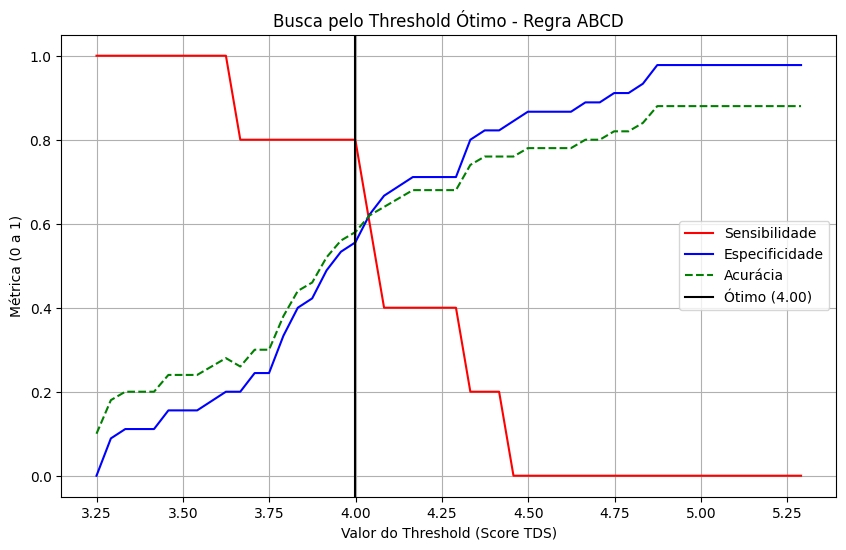

In [ ]:
def encontrar_threshold_otimo(df_resultados):
    # Filtrar apenas imagens que possuem rótulo real (Ground Truth)
    df_valid = df_resultados[df_resultados['Real'] != -1].copy()

    if df_valid.empty:
        print("Erro: Não há labels reais para calcular o threshold.")
        return None

    # Gerar candidatos a threshold baseados nos scores calculados
    # Testamos de 0.5 em 0.5, ou dentro da faixa de scores existentes
    min_score = df_valid['Score'].min()
    max_score = df_valid['Score'].max()
    candidatos = np.linspace(min_score, max_score, 50)

    historico_metricas = []

    for t in candidatos:
        y_pred = (df_valid['Score'] >= t).astype(int)
        y_true = df_valid['Real'].astype(int)

        # Matriz de Confusão manual
        tp = sum((y_pred == 1) & (y_true == 1))
        tn = sum((y_pred == 0) & (y_true == 0))
        fp = sum((y_pred == 1) & (y_true == 0))
        fn = sum((y_pred == 0) & (y_true == 1))

        # Cálculos das métricas exigidas
        acuracia = (tp + tn) / len(y_true)
        sensibilidade = tp / (tp + fn) if (tp + fn) > 0 else 0
        especificidade = tn / (tn + fp) if (tn + fp) > 0 else 0

        historico_metricas.append({
            'threshold': t,
            'acuracia': acuracia,
            'sensibilidade': sensibilidade,
            'especificidade': especificidade
        })

    df_otimizacao = pd.DataFrame(historico_metricas)

    # Critério de "Ótimo": Maior Acurácia onde Sensibilidade > 0.8 (exemplo)
    # Ou simplesmente o ponto onde a soma de Sensibilidade + Especificidade é máxima
    df_otimizacao['soma_sens_esp'] = df_otimizacao['sensibilidade'] + df_otimizacao['especificidade']
    melhor_t = df_otimizacao.loc[df_otimizacao['soma_sens_esp'].idxmax()]

    return df_otimizacao, melhor_t

# --- Execução e Plotagem ---
df_hist, melhor_ponto = encontrar_threshold_otimo(df)

print(f"=== Otimização Final ===")
print(f"Melhor Threshold Sugerido: {melhor_ponto['threshold']:.2f}")
print(f"Sensibilidade nesse ponto: {melhor_ponto['sensibilidade']:.2%}")
print(f"Acurácia nesse ponto: {melhor_ponto['acuracia']:.2%}")

# Visualização da curva
plt.figure(figsize=(10, 6))
plt.plot(df_hist['threshold'], df_hist['sensibilidade'], label='Sensibilidade', color='red')
plt.plot(df_hist['threshold'], df_hist['especificidade'], label='Especificidade', color='blue')
plt.plot(df_hist['threshold'], df_hist['acuracia'], label='Acurácia', color='green', linestyle='--')
plt.axvline(melhor_ponto['threshold'], color='black', label=f"Ótimo ({melhor_ponto['threshold']:.2f})")
plt.xlabel('Valor do Threshold (Score TDS)')
plt.ylabel('Métrica (0 a 1)')
plt.title('Busca pelo Threshold Ótimo - Regra ABCD')
plt.legend()
plt.grid(True)
plt.show()

# Visualização


=== Visualização dos Extremos ===
Gerando gráficos para o MELHOR caso (ISIC_0000069) e o PIOR caso (ISIC_0000096)...


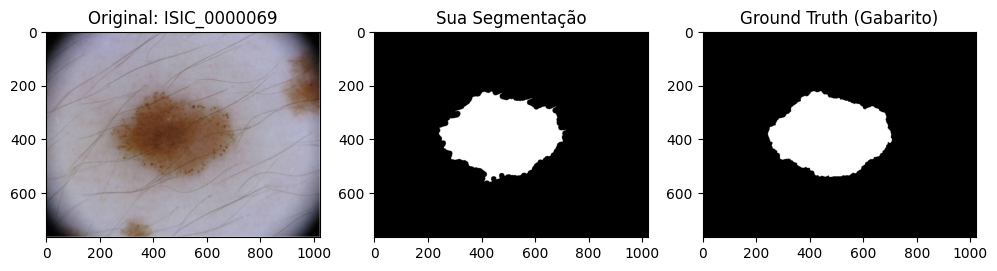

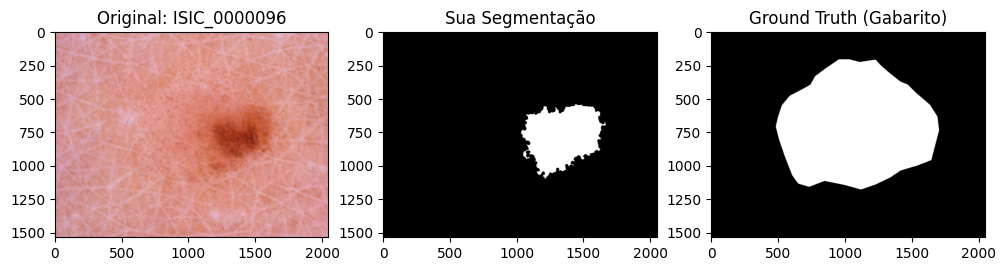

In [ ]:
def visualizar_comparativo(image_id_alvo):
    # Reconstrói os caminhos
    path_img = f"images/{image_id_alvo}.jpg"
    path_mask_true = f"masks/{image_id_alvo}_segmentation.png"

    if not os.path.exists(path_img): return

    # Carrega Original
    img = cv2.cvtColor(cv2.imread(path_img), cv2.COLOR_BGR2RGB)

    # Aplica remoção de pelo se for necessário (usando sua regra)
    indices_fios = ["ISIC_0000006", "ISIC_0000019", "ISIC_0000036", "ISIC_0000044"] # IDs aproximados
    if image_id_alvo in indices_fios: # Simplificação, ideal verificar pelo índice numérico se preferir
         img = remove_hair(img)

    # Gera a Sua Máscara de novo
    mask_pred = segmentar_lesao(img)

    # Carrega a Máscara Real
    if os.path.exists(path_mask_true):
        mask_true = cv2.imread(path_mask_true, cv2.IMREAD_GRAYSCALE)
    else:
        mask_true = np.zeros_like(mask_pred)

    # Plota
    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    ax[0].imshow(img)
    ax[0].set_title(f"Original: {image_id_alvo}")
    ax[1].imshow(mask_pred, cmap='gray')
    ax[1].set_title("Sua Segmentação")
    ax[2].imshow(mask_true, cmap='gray')
    ax[2].set_title("Ground Truth (Gabarito)")
    plt.show()

print("\n=== Visualização dos Extremos ===")
print(f"Gerando gráficos para o MELHOR caso ({melhor_dice['ID']}) e o PIOR caso ({pior_dice['ID']})...")

visualizar_comparativo(melhor_dice['ID']) # Mostra a melhor
visualizar_comparativo(pior_dice['ID'])   # Mostra a pior

#Geração de resultados em csv

In [ ]:
import pandas as pd

# 1. Criar o DataFrame a partir da sua lista de resultados
df_final = pd.DataFrame(resultados)

# 2. Renomear as colunas conforme sua solicitação e o enunciado
# Mapeamos "Score" para "TDS", "Predicao" para "Classificação do algoritmo" e "Real" para "Ground Truth"
df_tabela = df_final.rename(columns={
    "ID": "ID da imagem",
    "Score": "TDS",
    "Predicao": "Classificação do algoritmo",
    "Real": "Ground Truth"
})

# Reorganizar as colunas na ordem pedida
colunas = ["ID da imagem", "Dice", "IoU", "A", "B", "C", "D", "TDS", "Classificação do algoritmo", "Ground Truth"]
df_tabela = df_tabela[colunas]

# 3. Converter os rótulos numéricos (0/1) para texto para o relatório final
mapeamento = {1: "Maligno", 0: "Benigno", -1: "N/A"}
df_tabela["Classificação do algoritmo"] = df_tabela["Classificação do algoritmo"].map(mapeamento)
df_tabela["Ground Truth"] = df_tabela["Ground Truth"].map(mapeamento)

# 4. Calcular Média e Desvio Padrão para as colunas numéricas (Dice, IoU, A, B, C, D, TDS)
colunas_numericas = ["Dice", "IoU", "A", "B", "C", "D", "TDS"]
medias = df_tabela[colunas_numericas].mean()
desvios = df_tabela[colunas_numericas].std()

# 5. Criar as linhas de resumo (Média e Desvio)
linha_media = {col: round(medias[col], 4) if col in colunas_numericas else "" for col in colunas}
linha_media["ID da imagem"] = "Média"

linha_desvio = {col: round(desvios[col], 4) if col in colunas_numericas else "" for col in colunas}
linha_desvio["ID da imagem"] = "Desvio"

# 6. Unificar os dados e as linhas de estatística
df_exportar = pd.concat([df_tabela, pd.DataFrame([linha_media, linha_desvio])], ignore_index=True)

# 7. Salvar o arquivo CSV (usando ';' como separador para facilitar abertura no Excel)
nome_arquivo = "tabela_resultados_ABCD_PDI.csv"
df_exportar.to_csv(nome_arquivo, index=False, sep=';', encoding='utf-8-sig')

print(f"Planilha '{nome_arquivo}' gerada com sucesso para entrega!")

Planilha 'tabela_resultados_ABCD_PDI.csv' gerada com sucesso para entrega!
